# Analysis of Spatial Scaling Effect on Skeleton Data

This notebook analyzes the effect of spatial scaling on skeleton keypoints extracted by MediaPipe. We will:

1. Import and load skeleton data
2. Define parameters and scale factors
3. Apply spatial scaling to skeletons
4. Visualize original vs scaled skeletons (single frame & sequence)
5. Summarize displacement statistics
6. Plot displacement histograms
7. Compare multiple scale factors side-by-side
8. Compare full-body samples from 5 speakers
9. Compare original vs augmented (spatial scale)
10. Compare multiple scale values (full body)

---

In [ ]:
# 1. Import Libraries and Load Data
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load skeleton data (adjust path as needed)
pickle_file = '../data/pickle/pose_bisindo.pkl'
with open(pickle_file, 'rb') as f:
    data = pickle.load(f)

print(f"Total videos in dataset: {len(data)}")
print("Sample Video IDs:", list(data.keys())[:10])

Total videos in dataset: 750
Sample Video IDs: ['P01_S001_R01', 'P01_S001_R02', 'P01_S001_R03', 'P01_S001_R04', 'P01_S001_R05', 'P02_S001_R01', 'P02_S001_R02', 'P02_S001_R03', 'P02_S001_R04', 'P02_S001_R05']


In [ ]:
# 2. Parameter Settings for Spatial Scale Analysis
SELECTED_VIDEO_ID = 'P1_S15_R1'   # Target video for analysis
SELECTED_START_FRAME = 35            # Target starting frame for visualization
SCALE_FACTORS = [0.8, 1.0, 1.2]     # List of scale factors to analyze

if SELECTED_VIDEO_ID not in data:
    raise ValueError(f"Video '{SELECTED_VIDEO_ID}' not found!")

kp = data[SELECTED_VIDEO_ID]['keypoints']  # shape: (T, K, 2)
T, K, _ = kp.shape

print(f"Video           : {SELECTED_VIDEO_ID}")
print(f"Total frames    : {T}")
print(f"Total keypoints : {K} per frame")

Video           : P01_S001_R01
Total frames    : 185
Total keypoints : 86 per frame


In [ ]:
# 3. Apply Spatial Scaling to Skeleton Data
class Scale(object):
    """
    Scale skeleton sequences by applying random scaling factors.

    Args:
        scale_range (tuple): Range of scaling factors (min, max).
    """

    def __init__(self, scale_range=(0.8, 1.2)) -> None:
        self.scale_range = scale_range

    def __call__(self, skeleton, **kwargs):
        T = skeleton.shape[0]
        scales = np.random.uniform(*self.scale_range, size=T)
        scaled_skeleton = skeleton * scales[:, np.newaxis, np.newaxis]
        return scaled_skeleton

# Example: scale a single frame
frame_idx = min(SELECTED_START_FRAME, T - 1)
frame_ori = kp[frame_idx].copy()
scaled_frames = {s: scale_skeleton(frame_ori, s) for s in SCALE_FACTORS}

## 4. Visualize Original vs Scaled Skeleton (Single Frame, Hands Only)

We compare the original and scaled skeletons for a single frame, focusing on hand keypoints.

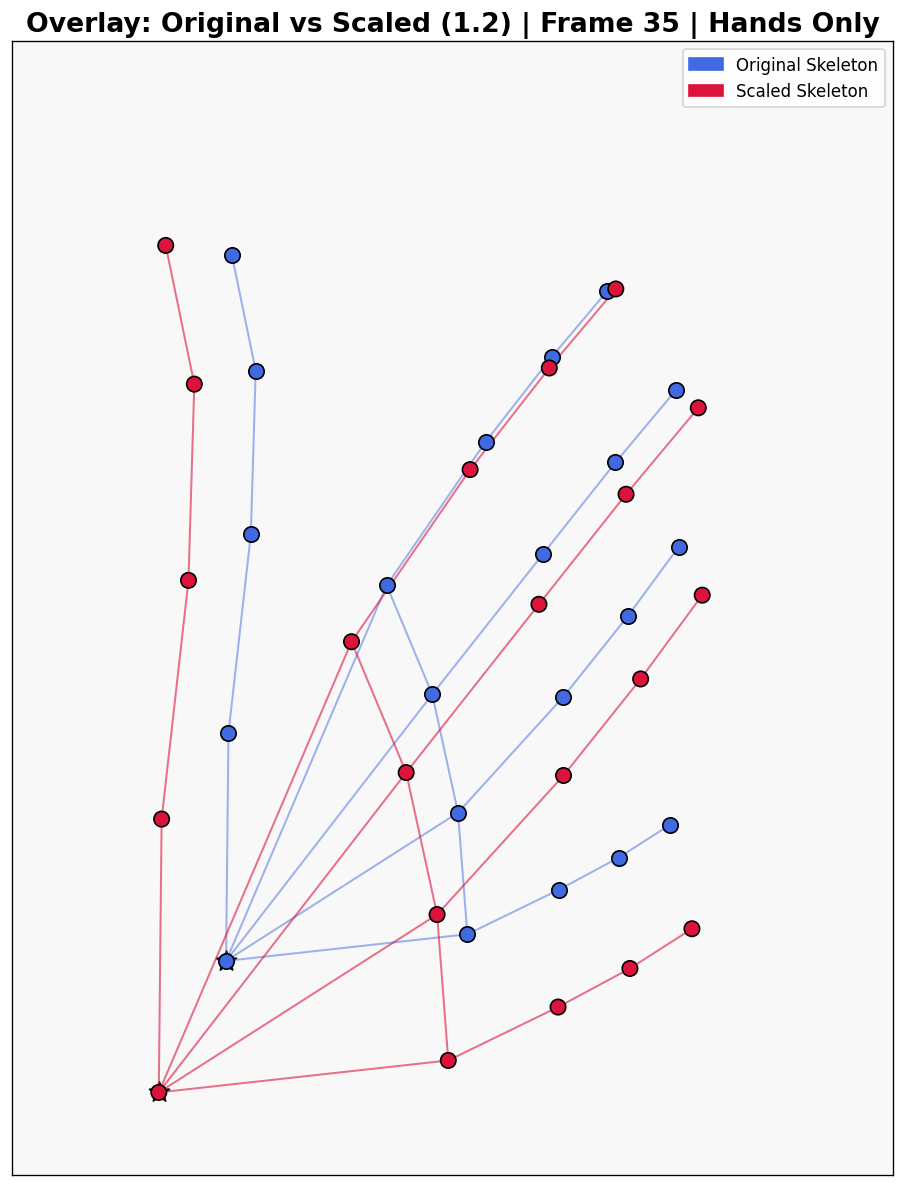

In [ ]:
# === FINAL VERSION: Overlay Original vs Scaled (Clean & Paper-Ready) ===

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ===== CONFIG =====
scale_factor = 1.2
margin = 0.05

# ===== DATA =====
frame_ori = kp[frame_idx].copy()
frame_scaled = scaled_frames[scale_factor]

# ===== MASK =====
K = frame_ori.shape[0]

hand_mask = np.zeros(K, dtype=bool)
hand_mask[:min(42, K)] = True

valid_ori = ((frame_ori[:, 0] != 0) | (frame_ori[:, 1] != 0)) & hand_mask
valid_scaled = ((frame_scaled[:, 0] != 0) | (frame_scaled[:, 1] != 0)) & hand_mask
valid = valid_ori & valid_scaled

# ===== DISPLACEMENT (for highlight only) =====
disp = np.zeros(K)
disp[valid] = np.linalg.norm(frame_scaled[valid] - frame_ori[valid], axis=1)

changed_pts = np.where((disp > 0) & valid)[0]

main_label_idx = None
if len(changed_pts) > 0:
    main_label_idx = changed_pts[np.argmax(disp[changed_pts])]

# ===== HAND SKELETON EDGES =====
hand_edges = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]

connections = []
for u,v in hand_edges:
    connections.append((u,v))
for u,v in hand_edges:
    connections.append((u+21,v+21))

# ===== PLOT =====
fig, ax = plt.subplots(figsize=(10, 10), dpi=120)

ax.set_title(
    f"Overlay: Original vs Scaled ({scale_factor}) | Frame {frame_idx} | Hands Only",
    fontsize=16, fontweight='bold'
)

# --- ORIGINAL SKELETON (BLUE) ---
for u,v in connections:
    if valid[u] and valid[v]:
        ax.plot([frame_ori[u,0], frame_ori[v,0]],
                [-frame_ori[u,1], -frame_ori[v,1]],
                c='royalblue', alpha=0.5, linewidth=1.2)

# --- SCALED SKELETON (RED) ---
for u,v in connections:
    if valid[u] and valid[v]:
        ax.plot([frame_scaled[u,0], frame_scaled[v,0]],
                [-frame_scaled[u,1], -frame_scaled[v,1]],
                c='crimson', alpha=0.6, linewidth=1.2)

# --- ORIGINAL POINTS ---
ax.scatter(frame_ori[valid,0], -frame_ori[valid,1],
           s=85, c='royalblue', edgecolors='black',
           zorder=3)

# --- SCALED POINTS ---
point_colors = [
    'crimson' if j in changed_pts else 'forestgreen'
    for j in np.where(valid)[0]
]

ax.scatter(frame_scaled[valid,0], -frame_scaled[valid,1],
           s=85, c=point_colors, edgecolors='black',
           zorder=4)

# --- HIGHLIGHT MOST SHIFTED POINT ---
if main_label_idx is not None:
    x1, y1 = frame_ori[main_label_idx,0], -frame_ori[main_label_idx,1]
    x2, y2 = frame_scaled[main_label_idx,0], -frame_scaled[main_label_idx,1]

    ax.scatter(x1, y1, s=160, c='royalblue', marker='*', edgecolors='black')
    ax.scatter(x2, y2, s=160, c='crimson', marker='*', edgecolors='black')

# ===== FORMAT =====
x_valid = frame_ori[valid,0]
y_valid = -frame_ori[valid,1]

ax.set_xlim(x_valid.min()-margin, x_valid.max()+margin)
ax.set_ylim(y_valid.min()-margin, y_valid.max()+margin)

ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('#f8f8f8')

# ===== LEGEND =====
blue_patch = mpatches.Patch(color='royalblue', label='Original Skeleton')
red_patch = mpatches.Patch(color='crimson', label='Scaled Skeleton')

ax.legend(handles=[blue_patch, red_patch], loc='upper right')

plt.tight_layout()
plt.show()